In [1]:
import numpy as np
import os.path
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import open3d as o3d

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
def sick2txt(top_path, fn):
    p = Path(top_path)
    gbl_file = list(p.glob('SICK*'+fn+'*.gbl'))[0]
    %run CBL_GBL_Processing_UMB.py --inFiles $gbl_file --verbose
    txt_file = Path(os.fspath(gbl_file)[:-3]+'txt')
    pcd_raw=np.loadtxt(txt_file,delimiter=',',usecols=(0,1,2,6,7))
    first_inds = np.argwhere(pcd_raw[:,4]==1)[:,0]
    first_returns = pcd_raw[first_inds,:]
    norm_int_inds = np.argwhere((first_returns[:,3]>50) & (first_returns[:,3]<1000))[:,0]
    pcd_use = first_returns[norm_int_inds,:]
    np.savetxt(Path(p,fn+'.txt'), pcd_use, delimiter=',',fmt=('%7.5f','%7.5f','%7.5f','%3.0f','%d'))
    return pcd_raw, pcd_use

def cart2sph_np(pcd_np):
    pcd_sph = np.zeros(pcd_np.shape) # preallocate
    # radius
    pcd_sph[:,0] = np.sqrt(pcd_np[:,0]**2+pcd_np[:,1]**2+pcd_np[:,2]**2)
    # azimuth angle
    pcd_sph[:,1] = np.arctan2(np.sqrt(pcd_np[:,0]**2+pcd_np[:,1]**2), pcd_np[:,2]) * 180.0/np.pi
    # elevation angle
    pcd_sph[:,2] = np.arctan2(pcd_np[:,1], pcd_np[:,0]) * 180.0/np.pi
    # intensity
    pcd_sph[:,3] = pcd_np[:,3]
    # return number (it is much less noisy if you feed in just the first returns)
    pcd_sph[:,4] = pcd_np[:,4]
    return pcd_sph

def rob_andrieu_image(pcd_sph, low=0):
    if low==1: # 0.5 degree pixel size
        im = np.zeros((270,720)) ; num_points = np.zeros((270,720)) ; sf = 2
    else: # 0.25 degree pixel size
        im = np.zeros((540,1440)) ; num_points = np.zeros((540,1440)) ; sf = 4
    for i in range(pcd_sph.shape[0]-1):
        # row of 0.25 or 0.5 degree pixels determined by azimuth
        r = np.round(pcd_sph[i,1]*sf).astype('int') 
        # column of 0.25 or 0.5 degree pixels determined by elevation
        c = np.round(pcd_sph[i,2]*sf).astype('int')
        if r <= (im.shape[0]-1):
            im[r-1,c-1] += pcd_sph[i,3] # add the intensity to the pixel
            num_points[r-1,c-1] += 1 # add to the count of points included in that pixel
    fill_ones = np.argwhere(num_points==0) # find the empty pixels (no points)
    num_points[fill_ones[:,0],fill_ones[:,1]] += 1 # avoid dividing by zero when averaging
    #im_out = np.flipud(np.divide(im,num_points)) # flip the image (upsidedown scanner)
    #moved this to outside the function pending the scanner orientation
    im_out = np.divide(im,num_points) #average intensity in each pixel
    return im_out

def rob_andrieu_image_correct(im):
    new_im = (im/im.max()*255).astype(np.uint8) # normalize to 0-255
    eq_im = cv2.equalizeHist(new_im) # histogram equalization
    blur_im = cv2.medianBlur(eq_im,5) # blur out any TLS skips if desired
    return eq_im, blur_im

def display_andrieu_image(im,save=0,savefile=None,low=2,orientation='up'):
    plt.figure(figsize=(15,6))
    plt.imshow(im[:-1,:-1],cmap='gray')
    if low==1:
        res='0.5'
    else:
        res='0.25'
    plt.title('Raw point-cloud to 2-D Andrieu projection - '+res+' degree pixels')
    plt.xlabel('Azimuth (degrees)')
    plt.ylabel('Elevation (degrees)')
    plt.xticks([0*low,180*low,360*low,540*low,720*low],['0','90','180','270','360'])
    if orientation=='up':
        plt.yticks([0*low,30*low,60*low,90*low,120*low,150*low,180*low,210*low,240*low,270*low],
               ['0','15','30','45','60','75','90','105','120','135'])
    else:
        plt.yticks([0*low,30*low,60*low,90*low,120*low,150*low,180*low,210*low,240*low,270*low],
               ['135','120','105','90','75','60','45','30','15','0'])
    plt.tight_layout()
    if save==1:
        plt.savefig(savefile,dpi=300)
    else:
        plt.show()
    return None

In [3]:
#messing with andreiu images
def cart2sph_np(pcd_np):
    pcd_sph = np.zeros(pcd_np.shape) # preallocate
    # radius
    pcd_sph[:,0] = np.sqrt(pcd_np[:,0]**2+pcd_np[:,1]**2+pcd_np[:,2]**2)
    # elevation angle
    pcd_sph[:,1] = np.arctan2(np.sqrt(pcd_np[:,0]**2+pcd_np[:,1]**2), pcd_np[:,2]) * 180.0/np.pi
    # azimuthal angle
    pcd_sph[:,2] = np.arctan2(pcd_np[:,1], pcd_np[:,0]) * 180.0/np.pi
    # intensity
    pcd_sph[:,3] = pcd_np[:,3]
    # return number (it is much less noisy if you feed in just the first returns)
    pcd_sph[:,4] = pcd_np[:,4]
    return pcd_sph

def rob_andrieu_image(pcd_sph, low=0):
    if low==1: # 0.5 degree pixel size
        im = np.zeros((270,720)) ; num_points = np.zeros((270,720)) ; sf = 2
    else: # 0.25 degree pixel size
        im = np.zeros((540,1440)) ; num_points = np.zeros((540,1440)) ; sf = 4
    for i in range(pcd_sph.shape[0]-1):
        # row of 0.25 or 0.5 degree pixels determined by azimuth
        r = np.round(pcd_sph[i,1]*sf).astype('int') 
        # column of 0.25 or 0.5 degree pixels determined by elevation
        c = np.round(pcd_sph[i,2]*sf).astype('int')
        if r <= (im.shape[0]-1):
            im[r-1,c-1] += pcd_sph[i,3] # add the intensity to the pixel
            num_points[r-1,c-1] += 1 # add to the count of points included in that pixel
    fill_ones = np.argwhere(num_points==0) # find the empty pixels (no points)
    num_points[fill_ones[:,0],fill_ones[:,1]] += 1 # avoid dividing by zero when averaging
    #im_out = np.flipud(np.divide(im,num_points)) # flip the image (upsidedown scanner)
    #moved this to outside the function pending the scanner orientation
    im_out = np.divide(im,num_points) #average intensity in each pixel
    return im_out


def rob_andrieu_image_correct(im):
    new_im = (im/im.max()*255).astype(np.uint8) # normalize to 0-255
    eq_im = cv2.equalizeHist(new_im) # histogram equalization
    blur_im = cv2.medianBlur(eq_im,3) # blur out any TLS skips if desired
    return eq_im, blur_im

def display_andrieu_image(im,save=0,savefile=None,low=2,orientation='up',depthmap=0,depths=0):
    plt.figure(figsize=(15,6))
    plt.imshow(im[:-1,:-1],cmap='gray')
    if low==1:
        res='0.5'
    else:
        res='0.25'
    plt.title('Raw point-cloud to 2-D Andrieu projection - '+res+' degree pixels')
    plt.xlabel('Azimuth (degrees)')
    plt.ylabel('Elevation (degrees)')
    plt.xticks([0*low,180*low,360*low,540*low,720*low],['0','90','180','270','360'])
    if orientation=='up':
        plt.yticks([0*low,30*low,60*low,90*low,120*low,150*low,180*low,210*low,240*low,270*low],
               ['0','15','30','45','60','75','90','105','120','135'])
    else:
        plt.yticks([0*low,30*low,60*low,90*low,120*low,150*low,180*low,210*low,240*low,270*low],
               ['135','120','105','90','75','60','45','30','15','0'])
    if depthmap==1:
        #tick_int = depths.max()/255.0
        cbar = plt.colorbar(label='Depth (m)',fraction=0.046, pad=0.04)
        #cbar.set_ticks([0,51,102,153,204,255])
        #cbar.set_ticklabels(['0',str(np.around(tick_int*51,1)),str(np.around(tick_int*102,1)),str(np.around(tick_int*153,1)),
        #                     str(np.around(tick_int*204,1)),str(np.around(tick_int*255,1))])
    plt.tight_layout()
    if save==1:
        plt.savefig(savefile,dpi=300)
    plt.show()
    return None

def polar_image(pcd_sph):
    # 0.25 degree pixel size
    im = np.zeros((360,360))
    num_points = np.zeros((360,360))
    for i in range(pcd_sph.shape[0]-1):
        # row of 0.5 degree pixels determined by elevation
        r = np.round(pcd_sph[i,1]*np.cos(pcd_sph[i,2]*np.pi/180.0)*2+180).astype('int')
        # column of 0.5 degree pixels determined by elevation
        c = np.round(pcd_sph[i,1]*np.sin(pcd_sph[i,2]*np.pi/180.0)*2+180).astype('int')
        if ((r < 360) and (c < 360)):
            im[r-1,c-1] += pcd_sph[i,3] # add the intensity to the pixel
            num_points[r-1,c-1] += 1 # add to the count of points included in that pixel
    fill_ones = np.argwhere(num_points==0) # find the empty pixels (no points)
    num_points[fill_ones[:,0],fill_ones[:,1]] += 1 # avoid dividing by zero when averaging
    #im_out = np.flipud(np.divide(im,num_points)) # flip the image (upsidedown scanner)
    #moved this to outside the function pending the scanner orientation
    im_out = np.divide(im,num_points) #average intensity in each pixel
    return im_out

def display_polar_image(im,save=0,savefile=None):
    plt.figure(figsize=(5,5))
    plt.imshow(im,cmap='gray'),plt.axis('off')
    plt.title('Raw point-cloud to 2-D Polar projection')
    plt.tight_layout()
    if save==1:
        plt.savefig(savefile,dpi=300)
    plt.show()
    return None

def cart2cyl_np(pcd_np):
    pcd_cyl = np.zeros(pcd_np.shape)
    pcd_cyl[:, 0] = np.sqrt(pcd_np[:, 0]**2 + pcd_np[:, 1]**2)
    pcd_cyl[:, 1] = np.arctan2(pcd_np[:, 1], pcd_np[:, 0])
    pcd_cyl[:, 2] = pcd_np[:, 2]
    return pcd_cyl

def polar_down(pcd_np, rad_limit=2.5):
    pcd_cyl = cart2cyl_np(pcd_np)
    inds = np.argwhere((pcd_cyl[:, 0] <= rad_limit) &
                       (pcd_np[:, 2] >= 0))[:, 0]
    pcd_cyl_down = pcd_np[inds, :]
    return pcd_cyl_down

def cyl_down(pcd_np, rad_limit=2.5):
    pcd_cyl = cart2cyl_np(pcd_np)
    inds = np.argwhere((pcd_cyl[:, 0] <= rad_limit))[:, 0]
    pcd_cyl_down = pcd_np[inds, :]
    return pcd_cyl_down

In [4]:
# change to location of .gbl and .meta TLS files
top_path = 'C:/Users/roccis/rit_research/demos/'
# tag is whatever you named the TLS file without all the mumbo jumbo before and after
# Ex file: 'UMBCBL009_2024-03-28-00-18-47_AURSET17_060180_002019.799_1410266179.gbl'
# with tag: 'AURSET17'
tag = 'RS2'
# access the .gbl file and create a .txt file of all raw points, and a second .txt 
# file with trimmed filename only containing 1st returns and reasonable intensity values
pcd_raw, pcd_np = sick2txt(top_path, tag)

No spdlib module found. No spd or las files will be produced.
Processing 1 .gbl files
Currently processing C:\Users\roccis\rit_research\demos\SICK_2023-05-29-18-18-17_RS2_060180_001552.799_1873642506.gbl
CBL Version 2


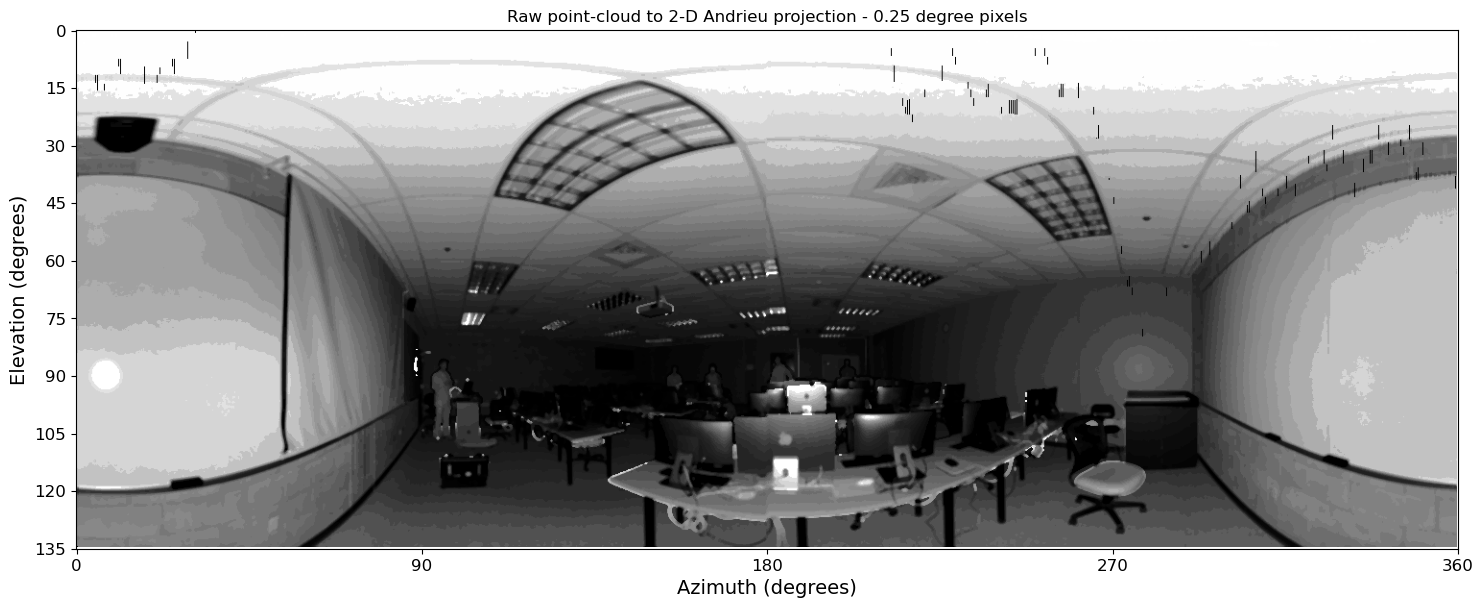

In [21]:
# xyz to r,theta,phi
pcd_sph = cart2sph_np(pcd_raw)
# 2D projection
and_im = rob_andrieu_image(pcd_sph)
# adjusting the contrast and smoothing out in attempts compensate for empty pixels 
# (not perfect pending angular resolution chosen)
eq_im, blur_im = rob_andrieu_image_correct(and_im)
# displaying and saving the projection
display_andrieu_image(blur_im,orientation='up',save=1,savefile=top_path+tag+'_intensity.png')

#and_im = rob_andrieu_image(pcd_sph, low=1)

#eq_im, blur_im = rob_andrieu_image_correct(and_im)

#display_andrieu_image(eq_im,low=1,save=1,savefile=top_path+tag+'_intensity.png')


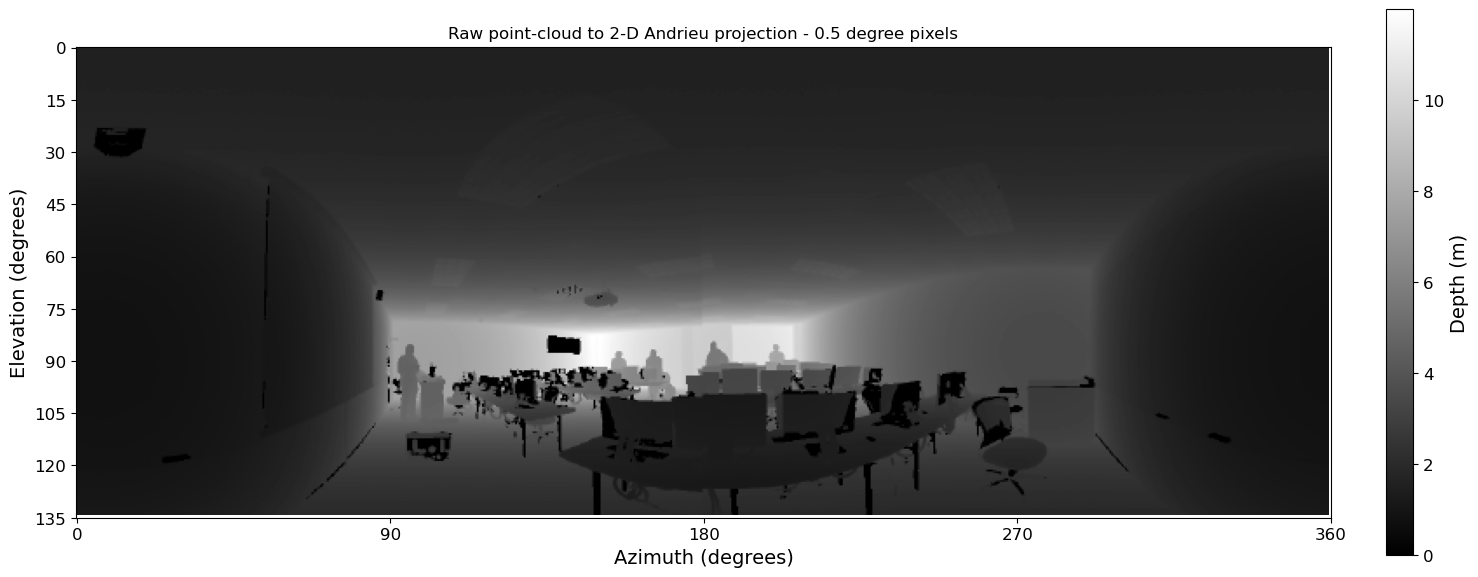

In [22]:
# same as above, but instead of intesnity we are displaying depth
pcd_firsts = pcd_raw[np.argwhere(pcd_raw[:,4]==1)[:,0],:]
depth = np.sqrt(pcd_firsts[:,0]**2+pcd_firsts[:,1]**2+pcd_firsts[:,2]**2)
pcd_firsts[:,3] = depth
pcd_sph = cart2sph_np(pcd_firsts)
and_im = rob_andrieu_image(pcd_sph,low=1)
eq_im, blur_im = rob_andrieu_image_correct(and_im)
display_andrieu_image(and_im,low=1,orientation='up',depthmap=1,depths=depth,save=1,savefile=top_path+tag+'_depth.png')

In [19]:
#experimental unsupervised segmentation
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pcd_np[:,:3])
pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=16), fast_normal_computation=True)

segment_models={}
segments={}
max_plane_idx=20
rest=pcd
d_threshold=0.02
for i in range(max_plane_idx):
    colors = plt.get_cmap("tab20")(i)
    segment_models[i], inliers = rest.segment_plane(distance_threshold=d_threshold,ransac_n=3,num_iterations=1000)
    segments[i]=rest.select_by_index(inliers)
    labels = np.array(segments[i].cluster_dbscan(eps=d_threshold*10, min_points=10))
    candidates=[len(np.where(labels==j)[0]) for j in np.unique(labels)]
    best_candidate=int(np.unique(labels)[np.where(candidates==np.max(candidates))[0]])
    print("the best candidate is: ", best_candidate)
    rest = rest.select_by_index(inliers, invert=True)+segments[i].select_by_index(list(np.where(labels!=best_candidate)[0]))
    segments[i]=segments[i].select_by_index(list(np.where(labels==best_candidate)[0]))
    segments[i].paint_uniform_color(list(colors[:3]))
    print("pass",i+1,"/",max_plane_idx,"done.")
labels = np.array(rest.cluster_dbscan(eps=0.05, min_points=5))
max_label = labels.max()
print(f"point cloud has {max_label + 1} clusters")

colors = plt.get_cmap("tab10")(labels / (max_label if max_label > 0 else 1))
colors[labels < 0] = 0
rest.colors = o3d.utility.Vector3dVector(colors[:, :3])

# o3d.visualization.draw_geometries([segments.values()])
# o3d.visualization.draw_geometries([segments[i] for i in range(max_plane_idx)]+[rest])
o3d.visualization.draw_geometries([segments[i] for i in range(max_plane_idx)]+[rest],zoom=0.3199,front=[0.30159062875123849, 0.94077325609922868, 0.15488309545553303],lookat=[-3.9559999108314514, -0.055000066757202148, -0.27599999308586121],up=[-0.044411423633999815, -0.138726419067636, 0.98753122516983349])
# o3d.visualization.draw_geometries([rest])

the best candidate is:  0
pass 1 / 20 done.
the best candidate is:  0
pass 2 / 20 done.
the best candidate is:  0
pass 3 / 20 done.
the best candidate is:  0
pass 4 / 20 done.
the best candidate is:  1
pass 5 / 20 done.
the best candidate is:  3
pass 6 / 20 done.
the best candidate is:  2
pass 7 / 20 done.
the best candidate is:  4
pass 8 / 20 done.
the best candidate is:  2
pass 9 / 20 done.
the best candidate is:  0
pass 10 / 20 done.
the best candidate is:  6
pass 11 / 20 done.
the best candidate is:  5
pass 12 / 20 done.
the best candidate is:  1
pass 13 / 20 done.
the best candidate is:  0
pass 14 / 20 done.
the best candidate is:  0
pass 15 / 20 done.
the best candidate is:  11
pass 16 / 20 done.
the best candidate is:  17
pass 17 / 20 done.
the best candidate is:  8
pass 18 / 20 done.
the best candidate is:  11
pass 19 / 20 done.
the best candidate is:  0
pass 20 / 20 done.
point cloud has 929 clusters
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height an

In [5]:
#exploring individual files to understand data acquisition
p = Path(top_path)
gbl_file = list(p.glob('SICK*'+tag+'*.gbl'))[0]
txt_file = Path(os.fspath(gbl_file)[:-3]+'txt')
pcd=np.loadtxt(txt_file,delimiter=',')
pcd.shape

(787502, 8)

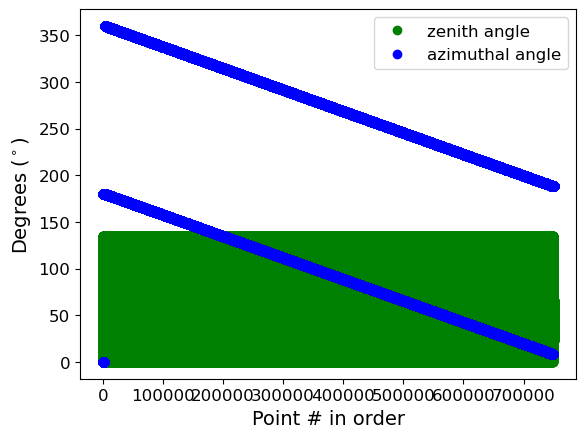

In [6]:
num = 750000
plt.plot(pcd[:num,3],'go')
plt.plot(pcd[:num,4],'bo')
plt.legend(('zenith angle','azimuthal angle'))
plt.xlabel('Point # in order')
plt.ylabel(r'Degrees ($^\circ$)')
plt.show()

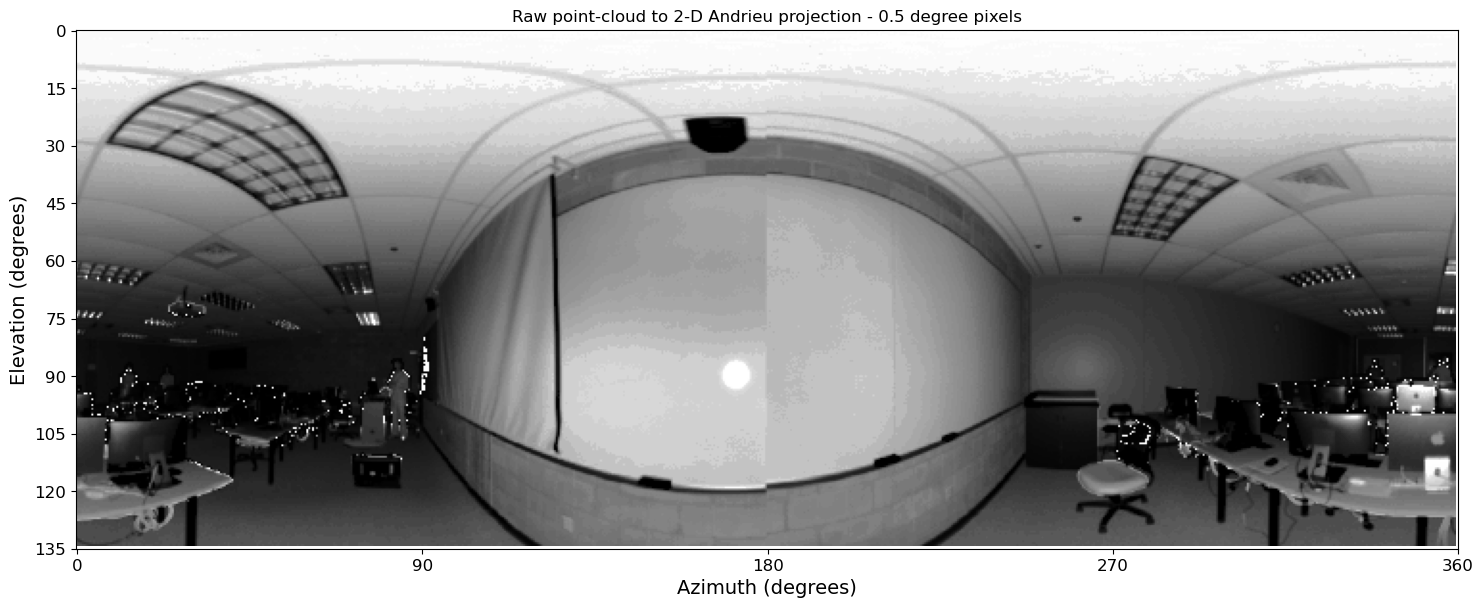

In [7]:
pcd_sph = np.zeros((pcd.shape[0],4))
pcd_sph[:,0] = pcd[:,5]
pcd_sph[:,1] = pcd[:,3]
pcd_sph[:,2] = pcd[:,4]
pcd_sph[:,3] = pcd[:,6]

and_im = rob_andrieu_image(pcd_sph, low=1)
eq_im, blur_im = rob_andrieu_image_correct(and_im)
display_andrieu_image(eq_im,low=1)